In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [2]:
cohorts = con.execute("""
    WITH first_order AS (
        SELECT 
            c.customer_unique_id,
            DATE_TRUNC('month', MIN(o.order_purchase_timestamp::TIMESTAMP)) AS cohort_month
        FROM orders o
        JOIN customers c USING (customer_id)
        WHERE o.order_status NOT IN ('canceled', 'unavailable')
        GROUP BY c.customer_unique_id
    ),
    all_orders AS (
        SELECT 
            c.customer_unique_id,
            f.cohort_month,
            DATE_TRUNC('month', o.order_purchase_timestamp::TIMESTAMP) AS order_month
        FROM orders o
        JOIN customers c USING (customer_id)
        JOIN first_order f USING (customer_unique_id)
    )
    SELECT
        cohort_month::DATE AS cohort_month,
        DATEDIFF('month', cohort_month::DATE, order_month::DATE) AS period,
        COUNT(DISTINCT customer_unique_id) AS customers
    FROM all_orders
    GROUP BY cohort_month, period
    ORDER BY cohort_month, period
""").df()

print(f"Shape: {cohorts.shape}")
print(cohorts.head(10))

Shape: (246, 3)
  cohort_month  period  customers
0   2016-09-01       0          2
1   2016-10-01       0        290
2   2016-10-01       6          1
3   2016-10-01       9          1
4   2016-10-01      11          1
5   2016-10-01      13          1
6   2016-10-01      15          1
7   2016-10-01      17          1
8   2016-10-01      19          2
9   2016-10-01      20          2


In [3]:
# Pivot to matrix: rows = cohort months, columns = period numbers
pivot = cohorts.pivot_table(
    index="cohort_month", 
    columns="period", 
    values="customers"
)

# Cohort sizes (period 0 = first month, all customers)
cohort_sizes = pivot[0]

# Retention rate as percentage
retention = pivot.divide(cohort_sizes, axis=0).round(4) * 100

print("Cohort sizes (number of new customers per month):")
print(cohort_sizes.sort_index())
print(f"\nRetention matrix shape: {retention.shape}")

Cohort sizes (number of new customers per month):
cohort_month
2016-09-01       2.0
2016-10-01     290.0
2016-12-01       1.0
2017-01-01     752.0
2017-02-01    1690.0
2017-03-01    2571.0
2017-04-01    2325.0
2017-05-01    3541.0
2017-06-01    3102.0
2017-07-01    3822.0
2017-08-01    4130.0
2017-09-01    4075.0
2017-10-01    4392.0
2017-11-01    7190.0
2017-12-01    5439.0
2018-01-01    6951.0
2018-02-01    6357.0
2018-03-01    6931.0
2018-04-01    6698.0
2018-05-01    6586.0
2018-06-01    5920.0
2018-07-01    6016.0
2018-08-01    6209.0
Name: 0, dtype: float64

Retention matrix shape: (23, 32)


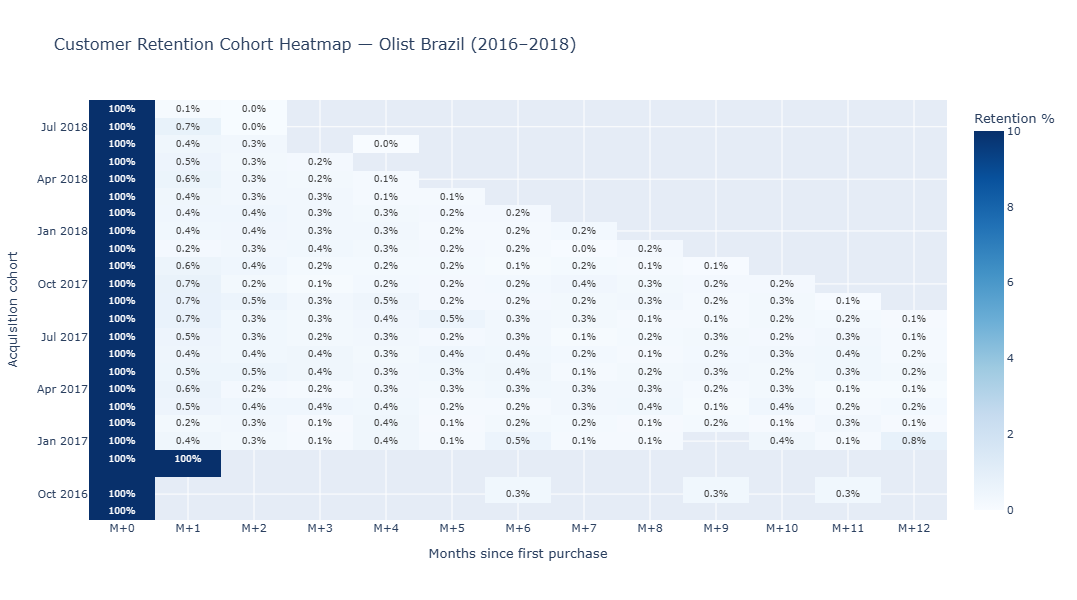


=== KEY INSIGHT ===
Average retention at M+1: 5.22%
Average retention at M+3: 0.26%
→ Olist has very low repeat purchase rate — most customers buy only once.
→ Business recommendation: invest in re-engagement campaigns and loyalty programs.


In [6]:
# Explicitly select only periods 0-12, sorted correctly
valid_periods = sorted([c for c in retention.columns if 0 <= c <= 12])
retention_12m = retention[valid_periods]

# Format cohort labels
cohort_labels = [str(c)[:7] for c in retention_12m.index]

# Build annotation text
text_vals = []
for row in retention_12m.values:
    text_row = []
    for val in row:
        if pd.isna(val):
            text_row.append("")
        elif val >= 99.9:
            text_row.append("100%")
        else:
            text_row.append(f"{val:.1f}%")
    text_vals.append(text_row)

fig = go.Figure(go.Heatmap(
    z=retention_12m.values,
    x=[f"M+{i}" for i in valid_periods],   # M+0, M+1 ... M+12
    y=cohort_labels,
    colorscale="Blues",
    reversescale=False,
    zmin=0,
    zmax=10,    # cap at 10% so low retention values show contrast
    text=text_vals,
    texttemplate="%{text}",
    textfont={"size": 9},
    hovertemplate=(
        "Cohort: %{y}<br>"
        "Period: %{x}<br>"
        "Retention: %{z:.1f}%<extra></extra>"
    ),
    colorbar=dict(title="Retention %")
))

fig.update_layout(
    title=dict(
        text="Customer Retention Cohort Heatmap — Olist Brazil (2016–2018)",
        font=dict(size=16)
    ),
    xaxis=dict(
        title="Months since first purchase",
        side="bottom",
        categoryorder="array",
        categoryarray=[f"M+{i}" for i in valid_periods]
    ),
    yaxis_title="Acquisition cohort",
    height=600,
    width=1000,
    font=dict(size=11)
)

fig.show()

# Print key insight
print("\n=== KEY INSIGHT ===")
avg_m1 = retention_12m[1].mean() if 1 in retention_12m.columns else 0
avg_m3 = retention_12m[3].mean() if 3 in retention_12m.columns else 0
print(f"Average retention at M+1: {avg_m1:.2f}%")
print(f"Average retention at M+3: {avg_m3:.2f}%")
print("→ Olist has very low repeat purchase rate — most customers buy only once.")
print("→ Business recommendation: invest in re-engagement campaigns and loyalty programs.")

In [10]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)

# Save as interactive HTML (better for portfolio than PNG)
fig.write_html("../docs/screenshots/01_cohort_heatmap.html")

# Save retention matrix as CSV
retention_12m.to_csv("../data/processed/01_cohort_retention.csv")

print("Saved:")
print("  docs/screenshots/01_cohort_heatmap.html")
print("  data/processed/01_cohort_retention.csv")

Saved:
  docs/screenshots/01_cohort_heatmap.html
  data/processed/01_cohort_retention.csv


In [12]:
print("COHORT ANALYSIS SUMMARY")
print(f"Total cohorts analysed : {len(cohort_sizes)}")
print(f"Date range             : Sep 2016 – Aug 2018")
print(f"Largest cohort         : Nov 2017 ({int(cohort_sizes.max()):,} customers)")
print(f"Avg M+1 retention      : {avg_m1:.2f}%")
print(f"Avg M+3 retention      : {avg_m3:.2f}%")
print()
print("FINDINGS:")
print("1. Retention drops from 100% → ~5% after just one month")
print("2. By M+3 virtually no customers return (<0.5%)")
print("3. Nov 2017 cohort is largest — likely Black Friday effect")
print("4. Growth in new customers is strong (2→7,190 per month)")

COHORT ANALYSIS SUMMARY
Total cohorts analysed : 23
Date range             : Sep 2016 – Aug 2018
Largest cohort         : Nov 2017 (7,190 customers)
Avg M+1 retention      : 5.22%
Avg M+3 retention      : 0.26%

FINDINGS:
1. Retention drops from 100% → ~5% after just one month
2. By M+3 virtually no customers return (<0.5%)
3. Nov 2017 cohort is largest — likely Black Friday effect
4. Growth in new customers is strong (2→7,190 per month)


In [13]:
con.close()
print("Connection closed")

Connection closed
